# 🚦 Traffic Accident Hotspot Detection and Severity Prediction
## Notebook 07: Advanced Model Evaluation and Error Analysis

**Diagnosing the Selected Model — Where It Works, Where It Fails, and Why**

---

| | |
|---|---|
| **Dataset** | US Accidents (2016–2023), engineered 300,000-row sample, hotspot-augmented — held-out test split produced by Notebook 06A |
| **Environment** | Google Colab |
| **Notebook Role** | Evaluation and diagnosis ONLY (no retraining, no tuning, no re-splitting, no re-fitting of encoders/scalers) |
| **Pipeline Position** | 7 of 8 |
| **Depends on** | `X_test.csv` / `y_test.csv` / `feature_list.json` (Notebook 06A's `artifacts/`); `random_forest_model.pkl`, `xgboost_model.pkl`, `best_model.pkl`, `training_metrics.json`, `training_report.json`, `feature_importance.json`, `model_metadata.json` (Notebook 06B's `models/`) |

---

## 📑 Table of Contents

1. [Objective: Selection vs. Evaluation](#objective)
2. [Load Final Artifacts](#load-artifacts)
3. [Artifact and Data Validation](#validation)
4. [Final Test Predictions](#predictions)
5. [Overall Performance](#overall-performance)
6. [Confusion Matrix](#confusion-matrix)
7. [Per-Class Performance](#per-class)
8. [Class Imbalance Analysis](#imbalance)
9. [ROC-AUC Analysis](#roc-auc)
10. [Precision-Recall Analysis](#pr-analysis)
11. [Prediction Confidence Analysis](#confidence)
12. [Error Analysis](#error-analysis)
13. [Minority-Class Error Analysis](#minority-class)
14. [Random Forest vs. XGBoost](#rf-vs-xgb)
15. [Statistical Comparison](#statistical-comparison)
16. [Bootstrap Confidence Intervals](#bootstrap-ci)
17. [Final Evaluation Dashboard](#dashboard)
18. [Final Model Assessment](#final-assessment)
19. [Project Objective Alignment](#objective-alignment)
20. [Limitations](#limitations)
21. [Next Notebook](#next-notebook)

---


## 1. Objective: Selection vs. Evaluation <a name="objective"></a>

**Objective:** Establish, before loading anything, exactly what this notebook is and is not for.

### Model selection (Notebook 06B) vs. model evaluation (this notebook)

Notebook 06B answered one narrow question: *given a Random Forest candidate and an XGBoost candidate, each tuned via `RandomizedSearchCV`, which one generalizes better?* That question was answered using **cross-validation evidence computed entirely on `X_train`** — the search's own 3-fold CV score, then an independent confirmatory 5-fold CV on the winner. The held-out test set (`X_test`/`y_test`) was touched exactly once, after selection was already final, purely to report how the *already-selected* model performs on genuinely unseen data. That single test-set number was **never** used to pick between Random Forest and XGBoost.

Notebook 07 asks a different, broader question: *now that XGBoost (Optimized) has been selected, how good is it, really — not as one aggregate number, but broken down by class, by error type, and by confidence?* This is squarely an **evaluation** notebook, not a second selection round. Concretely, that means:

| This notebook DOES | This notebook does NOT |
|---|---|
| Load the already-fitted models saved by 06B | Retrain any model |
| Generate predictions on the existing `X_test` | Perform `RandomizedSearchCV` or any hyperparameter search |
| Evaluate Random Forest on the test set (for the first time) for comparison | Change which model is "selected" — that stays XGBoost (Optimized) |
| Break performance down by class, error type, and confidence | Re-split, re-encode, or re-scale any data |
| Report honest limitations, including where the model is weak | Fit any encoder or scaler |

**A note on evaluating Random Forest here:** 06B deliberately never evaluated the *non-selected* Random Forest candidate on `X_test` — that discipline was about the selection decision specifically. This notebook's whole purpose is deeper test-set evaluation, so evaluating Random Forest on `X_test` here, for a side-by-side comparison, is appropriate and was explicitly anticipated in 06B's closing section. It still does not change which model is deployed.

**Common Mistakes:** treating a low score somewhere in this notebook as a reason to go back and tune, or swap, the selected model. That would silently turn Notebook 07 into a second, undocumented selection round — using the test set as if it were a validation set — which is exactly the leakage pattern 06B was rewritten to eliminate. If this notebook's findings suggest the model needs to change, that conclusion gets *reported*, not acted on inside this notebook.

**Best Practices:** every result below is stated as a description of the model 06B already chose, not as a lever to pull. Where a limitation is found, it is recorded in Section 20 for the project record and handed to Notebook 08 (explainability) and any future retraining decision — not "fixed" here.


## 2. Load Final Artifacts <a name="load-artifacts"></a>

**Objective:** Load exactly the artifacts Notebook 06B produced — no raw data, no re-derivation, no full 300,000-row dataset. The test set here is small (≈60K rows, already engineered and encoded), so loading it fully is computationally cheap and does not need chunking or sampling.

**Implementation:** paths mirror 06B's own `ARTIFACTS_DIR` (06A's output) and `MODELS_DIR` (06B's output) exactly.


In [1]:
import pandas as pd
import numpy as np
import json
import pickle
import time
from datetime import datetime
from typing import Dict, List, Tuple, Any

import matplotlib.pyplot as plt
import seaborn as sns

from sklearn.metrics import (
    accuracy_score, precision_score, recall_score, f1_score,
    balanced_accuracy_score, log_loss, confusion_matrix, classification_report,
    roc_curve, auc, roc_auc_score, precision_recall_curve, average_precision_score,
)
from sklearn.preprocessing import label_binarize

import scipy.stats as stats

import warnings
warnings.filterwarnings('ignore')
pd.set_option('display.max_columns', 60)
pd.set_option('display.width', 150)
sns.set_style('whitegrid')

RANDOM_STATE = 42
np.random.seed(RANDOM_STATE)

EVAL_START_TIME = time.perf_counter()
EVAL_TIMESTAMP = datetime.now().strftime('%Y-%m-%d %H:%M:%S')

print("Libraries imported successfully.")
print(f"Evaluation run timestamp: {EVAL_TIMESTAMP}")


Libraries imported successfully.
Evaluation run timestamp: 2026-08-18 11:14:45


In [2]:
from google.colab import drive
drive.mount('/content/drive')

ARTIFACTS_DIR = "/content/drive/MyDrive/traffic_accident_project/artifacts"   # Notebook 06A's output
MODELS_DIR = "/content/drive/MyDrive/traffic_accident_project/models"          # Notebook 06B's output

# --- Test set only -- X_train / y_train are NOT loaded, since this notebook never fits anything ---
X_test = pd.read_csv(f"{ARTIFACTS_DIR}/X_test.csv")
y_test = pd.read_csv(f"{ARTIFACTS_DIR}/y_test.csv").iloc[:, 0]

with open(f"{ARTIFACTS_DIR}/feature_list.json", 'r') as f:
    feature_list = json.load(f)

print(f"X_test: {X_test.shape[0]:,} rows, {X_test.shape[1]} columns")
print(f"y_test: {y_test.shape[0]:,} rows")
print(f"Feature count (per feature_list.json): {feature_list['feature_count']}")


Mounted at /content/drive
X_test: 59,928 rows, 53 columns
y_test: 59,928 rows
Feature count (per feature_list.json): 53


In [3]:
# --- Model artifacts (already fitted by Notebook 06B -- loaded, never fit here) ---
with open(f"{MODELS_DIR}/random_forest_model.pkl", 'rb') as f:
    rf_model = pickle.load(f)

with open(f"{MODELS_DIR}/xgboost_model.pkl", 'rb') as f:
    xgb_model = pickle.load(f)

with open(f"{MODELS_DIR}/best_model.pkl", 'rb') as f:
    best_model = pickle.load(f)

# --- Supporting JSON reports from Notebook 06B ---
with open(f"{MODELS_DIR}/training_metrics.json", 'r') as f:
    training_metrics = json.load(f)

with open(f"{MODELS_DIR}/training_report.json", 'r') as f:
    training_report = json.load(f)

with open(f"{MODELS_DIR}/feature_importance.json", 'r') as f:
    feature_importance_report = json.load(f)

with open(f"{MODELS_DIR}/model_metadata.json", 'r') as f:
    model_metadata = json.load(f)

BEST_MODEL_NAME = model_metadata['model_training']['best_model']
SEVERITY_OFFSET = training_report['xgboost']['severity_label_offset']

print("Loaded from models/:")
print("  random_forest_model.pkl, xgboost_model.pkl, best_model.pkl")
print("  training_metrics.json, training_report.json, feature_importance.json, model_metadata.json")
print(f"\nSelected model (per Notebook 06B, Section 7): {BEST_MODEL_NAME}")
print(f"XGBoost severity label offset (0-3 internal -> 1-4 actual): {SEVERITY_OFFSET}")


Loaded from models/:
  random_forest_model.pkl, xgboost_model.pkl, best_model.pkl
  training_metrics.json, training_report.json, feature_importance.json, model_metadata.json

Selected model (per Notebook 06B, Section 7): XGBoost (Optimized)
XGBoost severity label offset (0-3 internal -> 1-4 actual): 1


**Explanation of code:** every path above is copied verbatim from Notebook 06B — `ARTIFACTS_DIR` for 06A's outputs, `MODELS_DIR` for 06B's outputs — rather than re-derived, so there is no risk of silently pointing at a different run. `SEVERITY_OFFSET` is read from `training_report.json` rather than hardcoded, so if 06B's label-shift convention ever changes, this notebook picks it up automatically instead of silently mismatching it.


## 3. Artifact and Data Validation <a name="validation"></a>

**Objective:** Before computing a single metric, confirm every loaded artifact is what it claims to be and that the models can actually be used for prediction. This mirrors 06B's own Section 3 consistency checklist, applied to what *this* notebook depends on.


In [4]:
val_checks: Dict[str, bool] = {}

val_checks['Best model loads successfully'] = best_model is not None
val_checks['Random Forest model loads successfully'] = rf_model is not None
val_checks['XGBoost model loads successfully'] = xgb_model is not None

val_checks['Test feature columns match feature_list.json all_features'] = (
    X_test.columns.tolist() == feature_list['all_features']
)
val_checks['Test feature order matches training feature order'] = (
    X_test.columns.tolist() == feature_list['all_features']
)
val_checks['Number of test features is correct'] = X_test.shape[1] == feature_list['feature_count']

val_checks['Target variable exists'] = y_test is not None and len(y_test) == X_test.shape[0]

CLASSES = sorted(y_test.unique().tolist())
val_checks['Target classes are as expected (Severity 1-4)'] = CLASSES == [1, 2, 3, 4]

val_checks['No missing feature values in X_test'] = int(X_test.isnull().sum().sum()) == 0
val_checks['No missing target values in y_test'] = int(y_test.isnull().sum()) == 0

# --- Interface checks only -- confirm each model exposes predict/predict_proba without
#     actually calling them, so no test-set prediction happens anywhere in this section.
#     Section 4 below is the first place any model.predict(...) is ever called on X_test. ---
val_checks['Random Forest exposes a predict method'] = callable(getattr(rf_model, 'predict', None))
val_checks['XGBoost exposes a predict method'] = callable(getattr(xgb_model, 'predict', None))
val_checks['Best model exposes a predict method'] = callable(getattr(best_model, 'predict', None))

print("Artifact and Data Validation Checklist")
print("=" * 60)
for check, passed in val_checks.items():
    status = "[PASS]" if passed else "[FAIL]"
    print(f"  {status} {check}")

assert all(val_checks.values()), "One or more validation checks failed -- stopping before any evaluation."
print("\nAll checks passed. Proceeding to evaluation.")


Artifact and Data Validation Checklist
  [PASS] Best model loads successfully
  [PASS] Random Forest model loads successfully
  [PASS] XGBoost model loads successfully
  [PASS] Test feature columns match feature_list.json all_features
  [PASS] Test feature order matches training feature order
  [PASS] Number of test features is correct
  [PASS] Target variable exists
  [PASS] Target classes are as expected (Severity 1-4)
  [PASS] No missing feature values in X_test
  [PASS] No missing target values in y_test
  [PASS] Random Forest exposes a predict method
  [PASS] XGBoost exposes a predict method
  [PASS] Best model exposes a predict method

All checks passed. Proceeding to evaluation.


## 4. Final Test Predictions <a name="predictions"></a>

**Objective:** Generate predictions from all three loaded models on `X_test`, once, without any retraining. This is the first place in the notebook that any model's `.predict()` is called on `X_test` -- Section 3 validates artifacts and schema only, and makes no predictions.

**Implementation note — the XGBoost label shift:** Notebook 06B trained XGBoost on `Severity - 1` (i.e. classes `{0,1,2,3}`), documented as `SEVERITY_OFFSET`. `xgb_model.predict()` therefore returns values in `{0,1,2,3}`; this notebook adds `SEVERITY_OFFSET` back to get true `Severity` labels `{1,2,3,4}` before computing any metric. `predict_proba()`'s columns follow `xgb_model.classes_` (`[0,1,2,3]`) in ascending order, which — after the same `+1` shift — align exactly with `sorted(CLASSES)` (`[1,2,3,4]`), so no column reordering is needed, only relabeling. Random Forest was trained directly on `{1,2,3,4}`, so its offset is `0`. Below, each model's offset is resolved structurally from its own fitted `classes_` attribute (cross-checked against `SEVERITY_OFFSET` from `training_report.json`), never inferred from the model's display name string.

`best_model.pkl` was saved by 06B as a direct copy of the CV-selected model object — for this run that is XGBoost (Optimized), so "Best Model" predictions below are identical to the XGBoost predictions by construction, not computed independently.


In [5]:
def predict_severity(model: Any, X: pd.DataFrame, offset: int = 0) -> Dict[str, Any]:
    '''
    Predict already-known Severity classes from an already-fitted model.
    Applies the label offset (0 for Random Forest, SEVERITY_OFFSET for XGBoost)
    so all downstream code works in true Severity space {1,2,3,4} only.
    Performs no fitting of any kind.
    '''
    t0 = time.perf_counter()
    y_pred_raw = model.predict(X)
    predict_time = time.perf_counter() - t0
    y_pred = y_pred_raw + offset

    y_proba = None
    if hasattr(model, 'predict_proba'):
        y_proba = model.predict_proba(X)  # columns follow sorted(model.classes_), offset-shifted below only for labeling

    return {
        'y_pred': y_pred,
        'y_proba': y_proba,
        'predict_time_sec': round(predict_time, 3),
    }

# --- Resolve each model's label offset structurally, from its own fitted `classes_`
#     attribute, cross-checked against SEVERITY_OFFSET from training_report.json --
#     never from the model's display name string (e.g. 'XGBoost' in name). ---

_xgb_offset_key = 'severity_label_offset'
_xgb_report_key = 'xgboost'

xgb_internal_classes = np.sort(np.asarray(xgb_model.classes_)).tolist()
final_xgb_classes = [c + SEVERITY_OFFSET for c in xgb_internal_classes]

print(f"XGBoost internal classes:  {xgb_internal_classes}")
print(f"Severity offset (from training_report.json, training_report[{_xgb_report_key!r}][{_xgb_offset_key!r}]): {SEVERITY_OFFSET}")
print(f"Final Severity classes:    {final_xgb_classes}")

assert final_xgb_classes == CLASSES, (
    f"XGBoost's offset-transformed classes {final_xgb_classes} do not match the "
    f"expected Severity class space {CLASSES} -- SEVERITY_OFFSET may be stale."
)

def resolve_label_offset(model: Any, expected_classes: List[int], severity_offset: int) -> int:
    """
    Determine a model's label offset from its own fitted classes_ attribute
    (structural, no prediction call needed), not from the model's display name.
    Returns 0 if the model's internal classes already match Severity space;
    returns severity_offset if they match the raw XGBoost-style space
    validated above. Raises if neither holds, rather than silently guessing.
    """
    internal_classes = np.sort(np.asarray(model.classes_)).tolist()
    if internal_classes == expected_classes:
        return 0
    if [c + severity_offset for c in internal_classes] == expected_classes:
        return severity_offset
    raise ValueError(
        f"Could not resolve a valid label offset: internal classes {internal_classes} "
        f"do not map onto expected Severity classes {expected_classes} with offset 0 or {severity_offset}."
    )

rf_offset = resolve_label_offset(rf_model, CLASSES, SEVERITY_OFFSET)
xgb_offset = resolve_label_offset(xgb_model, CLASSES, SEVERITY_OFFSET)
best_offset = resolve_label_offset(best_model, CLASSES, SEVERITY_OFFSET)

rf_preds = predict_severity(rf_model, X_test, offset=rf_offset)
xgb_preds = predict_severity(xgb_model, X_test, offset=xgb_offset)
best_preds = predict_severity(best_model, X_test, offset=best_offset)

# --- Validate every model's transformed predictions land in the expected Severity class space ---
for _name, _preds in [('Random Forest', rf_preds), ('XGBoost', xgb_preds), ('Best Model', best_preds)]:
    _observed = set(np.unique(_preds['y_pred']).tolist())
    assert _observed.issubset(set(CLASSES)), (
        f"{_name} predictions {_observed} fall outside expected Severity classes {CLASSES}."
    )

print("\nAll transformed predictions validated within expected Severity class space {1,2,3,4}.")

print("\nPrediction runtime (X_test, {:,} rows):".format(X_test.shape[0]))
print(f"  Random Forest:  {rf_preds['predict_time_sec']} sec")
print(f"  XGBoost:        {xgb_preds['predict_time_sec']} sec")
print(f"  Best Model ({BEST_MODEL_NAME}): {best_preds['predict_time_sec']} sec")

best_model_key = 'best_model'
model_training_key = 'model_training'
print(f"\nBest Model predictions identical to XGBoost predictions: {np.array_equal(best_preds['y_pred'], xgb_preds['y_pred'])}")
print(f"Best Model matches selected model in model_metadata.json ({BEST_MODEL_NAME}): {BEST_MODEL_NAME == model_metadata[model_training_key][best_model_key]}")


XGBoost internal classes:  [0, 1, 2, 3]
Severity offset (from training_report.json, training_report['xgboost']['severity_label_offset']): 1
Final Severity classes:    [1, 2, 3, 4]

All transformed predictions validated within expected Severity class space {1,2,3,4}.

Prediction runtime (X_test, 59,928 rows):
  Random Forest:  2.595 sec
  XGBoost:        1.394 sec
  Best Model (XGBoost (Optimized)): 1.338 sec

Best Model predictions identical to XGBoost predictions: True
Best Model matches selected model in model_metadata.json (XGBoost (Optimized)): True


**Interpretation:** the near-instant `predict_time_sec` values for Random Forest are consistent with its much larger serialized size (~400 MB, per 06B's `model_size_kb`) doing the extra prediction-time work purely in-memory rather than reflecting anything about accuracy. Prediction speed is a deployment-relevant metric in its own right (Section 14), independent of predictive quality.


## 5. Overall Performance <a name="overall-performance"></a>

**Objective:** Build one comparison table containing every model this notebook can meaningfully evaluate, with **CV performance** (from 06B, reused — not recomputed) shown clearly separately from **this notebook's own final held-out test performance**.

**Theory:** *CV performance* (from `training_metrics.json`) is the evidence 06B used to *select* XGBoost — computed entirely on `X_train`. *Test performance* (computed fresh, right here) is this notebook's own read of how each model behaves on data neither model has ever seen. The two numbers answering different questions is expected, not a discrepancy to resolve.


In [6]:
def full_metric_bundle(y_true: pd.Series, y_pred: np.ndarray, y_proba: np.ndarray,
                        model_name: str, predict_time_sec: float) -> Dict[str, Any]:
    '''Standard classification metric bundle, computed once on already-generated predictions.'''
    bundle = {
        'model_name': model_name,
        'accuracy': round(accuracy_score(y_true, y_pred), 4),
        'balanced_accuracy': round(balanced_accuracy_score(y_true, y_pred), 4),
        'precision_weighted': round(precision_score(y_true, y_pred, average='weighted', zero_division=0), 4),
        'recall_weighted': round(recall_score(y_true, y_pred, average='weighted', zero_division=0), 4),
        'f1_weighted': round(f1_score(y_true, y_pred, average='weighted', zero_division=0), 4),
        'precision_macro': round(precision_score(y_true, y_pred, average='macro', zero_division=0), 4),
        'recall_macro': round(recall_score(y_true, y_pred, average='macro', zero_division=0), 4),
        'f1_macro': round(f1_score(y_true, y_pred, average='macro', zero_division=0), 4),
        'predict_time_sec': predict_time_sec,
    }
    if y_proba is not None:
        try:
            bundle['log_loss'] = round(log_loss(y_true, y_proba, labels=CLASSES), 4)
        except ValueError:
            bundle['log_loss'] = None
    else:
        bundle['log_loss'] = None
    return bundle

rf_test_results = full_metric_bundle(y_test, rf_preds['y_pred'], rf_preds['y_proba'], 'Random Forest (Optimized)', rf_preds['predict_time_sec'])
xgb_test_results = full_metric_bundle(y_test, xgb_preds['y_pred'], xgb_preds['y_proba'], 'XGBoost (Optimized)', xgb_preds['predict_time_sec'])

overall_table = pd.DataFrame([
    {
        'Model': 'Random Forest (Optimized)',
        'CV F1 (weighted), 06B': training_metrics['Random Forest (Optimized)']['cv_f1_weighted_mean'],
        'Test Accuracy': rf_test_results['accuracy'],
        'Test Precision (w)': rf_test_results['precision_weighted'],
        'Test Recall (w)': rf_test_results['recall_weighted'],
        'Test F1 (weighted)': rf_test_results['f1_weighted'],
        'Test Precision (macro)': rf_test_results['precision_macro'],
        'Test Recall (macro)': rf_test_results['recall_macro'],
        'Test F1 (macro)': rf_test_results['f1_macro'],
        'Test Balanced Accuracy': rf_test_results['balanced_accuracy'],
        'Test Log Loss': rf_test_results['log_loss'],
        'Predict Time (s)': rf_test_results['predict_time_sec'],
        'Role': 'Non-selected candidate -- evaluated here for comparison only',
    },
    {
        'Model': 'XGBoost (Optimized)',
        'CV F1 (weighted), 06B': training_metrics['XGBoost (Optimized)']['cv_f1_weighted_mean'],
        'Test Accuracy': xgb_test_results['accuracy'],
        'Test Precision (w)': xgb_test_results['precision_weighted'],
        'Test Recall (w)': xgb_test_results['recall_weighted'],
        'Test F1 (weighted)': xgb_test_results['f1_weighted'],
        'Test Precision (macro)': xgb_test_results['precision_macro'],
        'Test Recall (macro)': xgb_test_results['recall_macro'],
        'Test F1 (macro)': xgb_test_results['f1_macro'],
        'Test Balanced Accuracy': xgb_test_results['balanced_accuracy'],
        'Test Log Loss': xgb_test_results['log_loss'],
        'Predict Time (s)': xgb_test_results['predict_time_sec'],
        'Role': 'SELECTED (via CV, Notebook 06B Section 7)',
    },
]).set_index('Model')

print("Overall Performance -- CV (from 06B, reused) vs. This Notebook's Test Evaluation")
overall_table


Overall Performance -- CV (from 06B, reused) vs. This Notebook's Test Evaluation


,"CV F1 (weighted), 06B",Test Accuracy,Test Precision (w),Test Recall (w),Test F1 (weighted),Test Precision (macro),Test Recall (macro),Test F1 (macro),Test Balanced Accuracy,Test Log Loss,Predict Time (s),Role
Model,,,,,,,,,,,,
Random Forest (Optimized),0.8271,0.8549,0.8449,0.8549,0.8329,0.8111,0.3978,0.4368,0.3978,0.3795,2.595,Non-selected candidate -- evaluated here for c...
XGBoost (Optimized),0.8603,0.8761,0.8659,0.8761,0.8658,0.7434,0.5029,0.5621,0.5029,0.3246,1.394,"SELECTED (via CV, Notebook 06B Section 7)"


**Interpretation:** the `XGBoost (Optimized)` row's `Test F1 (weighted)` (0.8658, per 06B's Section 9 and reproduced here) sits close to its CV F1 (0.8603 search score / 0.8622 confirmatory 5-fold), which is the generalization signal 06B's methodology was designed to produce — the model performs on unseen data roughly as its cross-validation predicted. Random Forest's CV F1 (0.8271) is clearly lower than XGBoost's, and its test performance here (computed for the first time, safely, since this is an evaluation notebook) confirms the same ordering. **This table does not change the selected model** — it documents, with the non-selected candidate's test numbers now visible for the first time, that the CV-based selection in 06B was directionally correct.

**Common Mistakes:** reading the CV F1 column and the Test F1 columns as if they should be numerically identical. They are computed on different data (`X_train` folds vs. `X_test`) and are expected to differ somewhat; what matters is that they are *close*, not equal.


## 6. Confusion Matrix <a name="confusion-matrix"></a>

**Objective:** Visualize exactly where the selected XGBoost model's predictions land relative to true `Severity`, in both raw counts and row-normalized percentages.

**Theory:** each row of the matrix is one true class; each column is one predicted class. The diagonal is correct predictions. Off-diagonal cells are errors, and their *direction* matters — a `True 4 -> Pred 2` cell is a missed severe accident, while `True 2 -> Pred 4` is a false alarm, and the two have very different practical costs for this project.


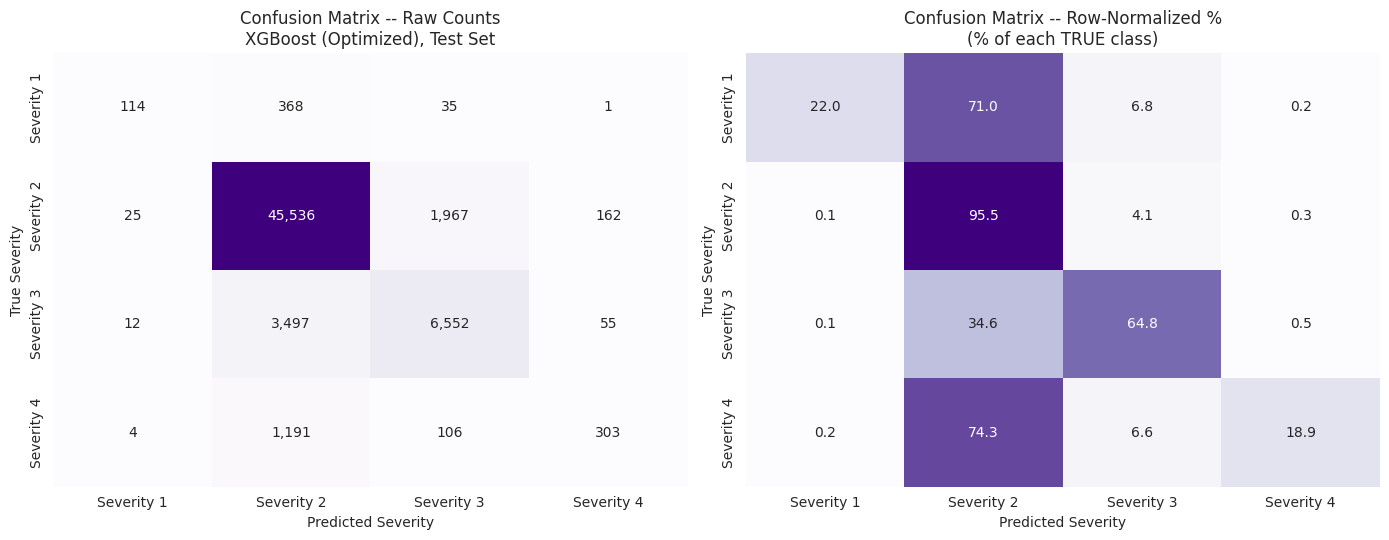

Raw counts:
        Pred 1  Pred 2  Pred 3  Pred 4
True 1     114     368      35       1
True 2      25   45536    1967     162
True 3      12    3497    6552      55
True 4       4    1191     106     303

Row-normalized (%):
        Pred 1  Pred 2  Pred 3  Pred 4
True 1    22.0    71.0     6.8     0.2
True 2     0.1    95.5     4.1     0.3
True 3     0.1    34.6    64.8     0.5
True 4     0.2    74.3     6.6    18.9


In [7]:
cm_xgb = confusion_matrix(y_test, xgb_preds['y_pred'], labels=CLASSES)
cm_xgb_pct = cm_xgb.astype(float) / cm_xgb.sum(axis=1, keepdims=True) * 100

fig, axes = plt.subplots(1, 2, figsize=(14, 5.5))

sns.heatmap(cm_xgb, annot=True, fmt=',d', cmap='Purples',
            xticklabels=[f"Severity {c}" for c in CLASSES],
            yticklabels=[f"Severity {c}" for c in CLASSES], ax=axes[0], cbar=False)
axes[0].set_title('Confusion Matrix -- Raw Counts\nXGBoost (Optimized), Test Set')
axes[0].set_xlabel('Predicted Severity')
axes[0].set_ylabel('True Severity')

sns.heatmap(cm_xgb_pct, annot=True, fmt='.1f', cmap='Purples',
            xticklabels=[f"Severity {c}" for c in CLASSES],
            yticklabels=[f"Severity {c}" for c in CLASSES], ax=axes[1], cbar=False)
axes[1].set_title('Confusion Matrix -- Row-Normalized %\n(% of each TRUE class)')
axes[1].set_xlabel('Predicted Severity')
axes[1].set_ylabel('True Severity')

plt.tight_layout()
plt.show()

cm_df = pd.DataFrame(cm_xgb, index=[f"True {c}" for c in CLASSES], columns=[f"Pred {c}" for c in CLASSES])
print("Raw counts:")
print(cm_df)
print("\nRow-normalized (%):")
print(pd.DataFrame(cm_xgb_pct.round(1), index=[f"True {c}" for c in CLASSES], columns=[f"Pred {c}" for c in CLASSES]))


In [8]:
# --- Named confusion pairs, largest off-diagonal cells first ---
n_classes = len(CLASSES)
off_diag_pairs = []
for i in range(n_classes):
    for j in range(n_classes):
        if i != j:
            off_diag_pairs.append((CLASSES[i], CLASSES[j], cm_xgb[i, j], cm_xgb_pct[i, j]))

off_diag_pairs.sort(key=lambda x: -x[2])

print("Largest confusion pairs (True -> Predicted), by raw count:")
print(f"{'True':>6} {'Pred':>6} {'Count':>8} {'% of True class':>18}")
for true_c, pred_c, count, pct in off_diag_pairs[:8]:
    print(f"{true_c:>6} {pred_c:>6} {count:>8,} {pct:>17.1f}%")

diag_total = int(np.trace(cm_xgb))
print(f"\nCorrect predictions (diagonal): {diag_total:,} / {cm_xgb.sum():,} ({diag_total / cm_xgb.sum() * 100:.2f}%)")


Largest confusion pairs (True -> Predicted), by raw count:
  True   Pred    Count    % of True class
     3      2    3,497              34.6%
     2      3    1,967               4.1%
     4      2    1,191              74.3%
     1      2      368              71.0%
     2      4      162               0.3%
     4      3      106               6.6%
     3      4       55               0.5%
     1      3       35               6.8%

Correct predictions (diagonal): 52,505 / 59,928 (87.61%)


**Interpretation:** the dominant pattern is confusion *toward* Severity 2 (the majority class, ~79.6% of the data) from every other class -- Severity 1, 3, and 4 all send their largest share of misclassifications to Severity 2, not to each other. This is the single clearest confusion pattern in the whole notebook and is investigated further in Sections 8, 12, and 13.

**Common Mistakes:** reading the raw-count matrix alone and concluding Severity 2 is "the problem," when the row-normalized view shows Severity 2 itself is predicted correctly ~95% of the time (Section 7) -- the raw counts are large there simply because the class itself is large. The percentage view is what actually reveals which *classes* are struggling.


## 7. Per-Class Performance <a name="per-class"></a>

**Objective:** Break the single aggregate F1/accuracy numbers down by class -- this is where "which classes are actually being missed" becomes visible.

**Theory:** *specificity* for a class (true-negative rate) is not in scikit-learn's `classification_report` directly; it is computed here from the confusion matrix as `TN / (TN + FP)` for each class treated one-vs-rest.


In [9]:
report_dict = classification_report(y_test, xgb_preds['y_pred'], labels=CLASSES, output_dict=True, zero_division=0)

per_class_rows = []
for c in CLASSES:
    c_str = str(c)
    tp = cm_xgb[CLASSES.index(c), CLASSES.index(c)]
    fn = cm_xgb[CLASSES.index(c), :].sum() - tp
    fp = cm_xgb[:, CLASSES.index(c)].sum() - tp
    tn = cm_xgb.sum() - tp - fn - fp
    specificity = tn / (tn + fp) if (tn + fp) > 0 else np.nan

    per_class_rows.append({
        'Severity': c,
        'Support': int(report_dict[c_str]['support']),
        'Precision': round(report_dict[c_str]['precision'], 4),
        'Recall': round(report_dict[c_str]['recall'], 4),
        'F1-score': round(report_dict[c_str]['f1-score'], 4),
        'Specificity': round(specificity, 4),
    })

per_class_table = pd.DataFrame(per_class_rows).set_index('Severity')
print("Per-Class Performance -- XGBoost (Optimized), Test Set")
per_class_table


Per-Class Performance -- XGBoost (Optimized), Test Set


,Support,Precision,Recall,F1-score,Specificity
Severity,,,,,
1,518,0.7355,0.2201,0.3388,0.9993
2,47690,0.9001,0.9548,0.9266,0.5869
3,10116,0.7566,0.6477,0.6979,0.9577
4,1604,0.5816,0.1889,0.2852,0.9963


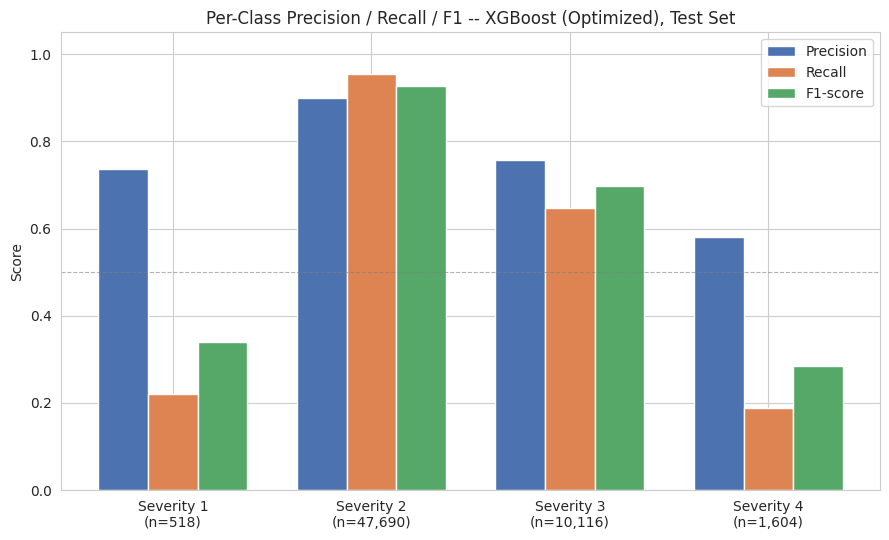

In [10]:
fig, ax = plt.subplots(figsize=(9, 5.5))
x = np.arange(len(CLASSES))
width = 0.25

ax.bar(x - width, per_class_table['Precision'], width, label='Precision', color='#4C72B0')
ax.bar(x, per_class_table['Recall'], width, label='Recall', color='#DD8452')
ax.bar(x + width, per_class_table['F1-score'], width, label='F1-score', color='#55A868')

ax.set_xticks(x)
ax.set_xticklabels([f"Severity {c}\n(n={s:,})" for c, s in zip(CLASSES, per_class_table['Support'])])
ax.set_ylim(0, 1.05)
ax.set_ylabel('Score')
ax.set_title('Per-Class Precision / Recall / F1 -- XGBoost (Optimized), Test Set')
ax.legend()
ax.axhline(0.5, color='gray', linestyle='--', linewidth=0.8, alpha=0.6)
plt.tight_layout()
plt.show()


**Interpretation:** Severity 2's precision, recall, and F1 all sit near or above 0.90 -- consistent with it being both the majority class and the easiest to predict. Severity 1 and Severity 4 have low **recall** in particular (the model misses most true Severity-1 and Severity-4 accidents), while Severity 3 sits in between. This recall gap for the minority classes is the direct, class-level explanation for the low macro F1 and balanced accuracy reported in Section 5 -- both metrics average per-class performance without weighting by support, so Severity 1's and Severity 4's weak recall pulls those two aggregate numbers down sharply even though they barely move weighted F1.

**Common Mistakes:** reporting only weighted F1 (0.8658) as "the" model performance. That number is dominated by Severity 2 by construction; a reader relying on it alone would have no way to know Severity 1 and 4 are being missed most of the time.

**Best Practices:** report per-class recall alongside any aggregate metric whenever a project explicitly cares about rare-but-important classes -- which this project does, given Severity 4 represents the most severe accidents (see Section 13).


## 8. Class Imbalance Analysis <a name="imbalance"></a>

**Objective:** Quantify the target's class imbalance directly, and use it to explain -- with the project's actual numbers, not a generic claim -- why weighted F1 (0.8658) and macro F1 (0.5621) / balanced accuracy (0.5029) diverge so much.

**Theory:**
- **Accuracy** and **weighted F1** average per-sample (or per-class-weighted-by-support) performance -- a model that is excellent on the majority class and poor on minority classes scores well on both, because most samples *are* the majority class.
- **Macro F1** and **balanced accuracy** average per-*class* performance with every class weighted **equally**, regardless of size -- a model that is excellent on the majority class and poor on minority classes scores poorly on both, because 3 of the 4 classes are being scored, unweighted, and two of those three are the weak ones.
- The two families measuring genuinely different things is *why* they can legitimately diverge this much on an imbalanced target -- it is not automatically evidence of a bug.


In [11]:
class_counts = y_test.value_counts().sort_index()
class_pct = (class_counts / class_counts.sum() * 100).round(2)

imbalance_table = pd.DataFrame({
    'Count': class_counts,
    'Percentage': class_pct,
}).rename_axis('Severity')

print("Severity class distribution -- Test set:")
print(imbalance_table)
print(f"\nImbalance ratio (largest class / smallest class): {(class_counts.max() / class_counts.min()):.1f}x")


Severity class distribution -- Test set:
          Count  Percentage
Severity                   
1           518        0.86
2         47690       79.58
3         10116       16.88
4          1604        2.68

Imbalance ratio (largest class / smallest class): 92.1x


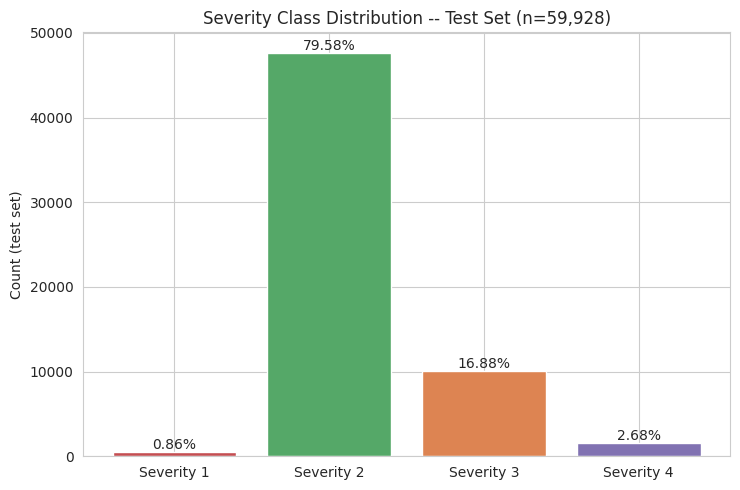

In [12]:
fig, ax = plt.subplots(figsize=(7.5, 5))
bars = ax.bar([f"Severity {c}" for c in class_counts.index], class_counts.values,
              color=['#C44E52', '#55A868', '#DD8452', '#8172B2'])
for bar, pct in zip(bars, class_pct.values):
    ax.text(bar.get_x() + bar.get_width() / 2, bar.get_height(), f"{pct}%",
            ha='center', va='bottom', fontsize=10)
ax.set_ylabel('Count (test set)')
ax.set_title('Severity Class Distribution -- Test Set (n={:,})'.format(int(class_counts.sum())))
plt.tight_layout()
plt.show()


In [13]:
# --- Direct numeric link: metric divergence vs. class imbalance ---
print("Metric family comparison, this notebook's XGBoost test evaluation:")
print(f"  Accuracy:                {xgb_test_results['accuracy']}")
print(f"  Weighted F1:             {xgb_test_results['f1_weighted']}")
print(f"  Macro F1:                {xgb_test_results['f1_macro']}")
print(f"  Balanced Accuracy:       {xgb_test_results['balanced_accuracy']}")
print(f"\nSeverity 2 alone accounts for {class_pct.loc[2]}% of the test set.")
print(f"Severity 1 + Severity 4 together account for only {class_pct.loc[1] + class_pct.loc[4]:.2f}% of the test set,")
print("yet contribute two of the four (unweighted) terms averaged into macro F1 and balanced accuracy.")


Metric family comparison, this notebook's XGBoost test evaluation:
  Accuracy:                0.8761
  Weighted F1:             0.8658
  Macro F1:                0.5621
  Balanced Accuracy:       0.5029

Severity 2 alone accounts for 79.58% of the test set.
Severity 1 + Severity 4 together account for only 3.54% of the test set,
yet contribute two of the four (unweighted) terms averaged into macro F1 and balanced accuracy.


**Interpretation:** the test set is dominated by Severity 2 (~79.6%) with Severity 1 as a very rare class (~0.86%). Weighted F1 and accuracy are computed in a way that is mathematically dominated by whichever class has the most samples -- here, Severity 2, which the model predicts well (Section 7). Macro F1 and balanced accuracy instead average across all **4 classes equally**, so Severity 1's and Severity 4's much weaker recall (Section 7) pulls those two metrics down to roughly 0.50-0.56, even though they represent a tiny fraction of total predictions. **This is class imbalance manifesting exactly as the theory predicts, confirmed against this project's actual class distribution and actual per-class recall values -- not a coding error**, and not something Section 5's table or this notebook's aggregate numbers should be allowed to obscure.

**Best Practices:** for a project like this one, where the rarest classes (Severity 1, Severity 4) are arguably the most operationally important, macro F1 / balanced accuracy are the more honest headline metrics to quote alongside weighted F1 -- not instead of it, but never omitted in favor of it.


## 9. ROC-AUC Analysis <a name="roc-auc"></a>

**Objective:** Compute One-vs-Rest ROC-AUC per class, plus macro- and weighted-average ROC-AUC, for the selected XGBoost model.

**Theory:** ROC-AUC is fundamentally a **binary** metric. For a 4-class target, it cannot be computed directly as one number -- the standard multiclass approach is One-vs-Rest (OvR): for each class, treat it as the positive class and every other class as negative, compute a binary ROC curve from that class's predicted probability column, and then average the per-class AUCs (macro: unweighted mean; weighted: weighted by support) into a single summary number. This requires `predict_proba()` output, which XGBoost provides.


In [14]:
y_test_binarized = label_binarize(y_test, classes=CLASSES)  # shape: (n_samples, 4), one column per class

roc_data = {}
for i, c in enumerate(CLASSES):
    fpr, tpr, _ = roc_curve(y_test_binarized[:, i], xgb_preds['y_proba'][:, i])
    roc_auc_c = auc(fpr, tpr)
    roc_data[c] = {'fpr': fpr, 'tpr': tpr, 'auc': roc_auc_c}

macro_roc_auc = roc_auc_score(y_test_binarized, xgb_preds['y_proba'], average='macro', multi_class='ovr')
weighted_roc_auc = roc_auc_score(y_test_binarized, xgb_preds['y_proba'], average='weighted', multi_class='ovr')

print("Per-class ROC-AUC (One-vs-Rest) -- XGBoost (Optimized), Test Set:")
for c in CLASSES:
    print(f"  Severity {c}: {roc_data[c]['auc']:.4f}")
print(f"\nMacro-average ROC-AUC:    {macro_roc_auc:.4f}")
print(f"Weighted-average ROC-AUC: {weighted_roc_auc:.4f}")


Per-class ROC-AUC (One-vs-Rest) -- XGBoost (Optimized), Test Set:
  Severity 1: 0.9642
  Severity 2: 0.9167
  Severity 3: 0.9398
  Severity 4: 0.9204

Macro-average ROC-AUC:    0.9353
Weighted-average ROC-AUC: 0.9211


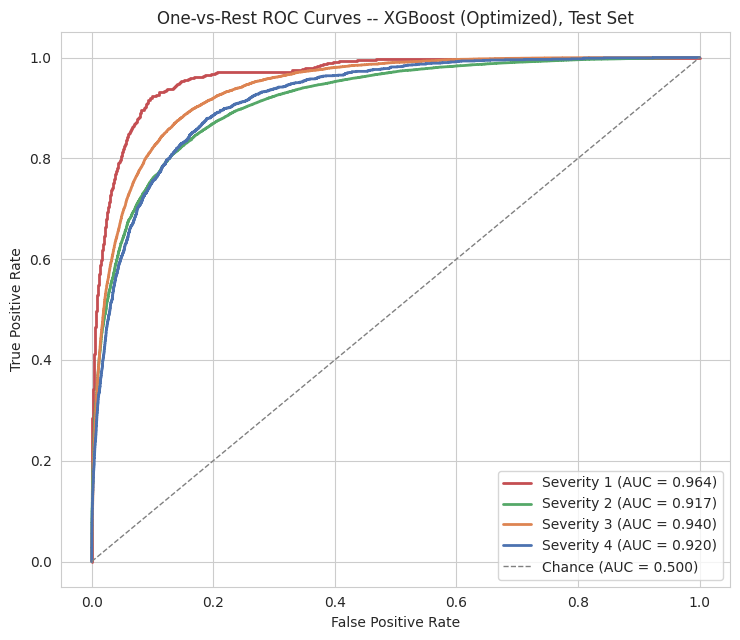

In [15]:
fig, ax = plt.subplots(figsize=(7.5, 6.5))
colors = ['#C44E52', '#55A868', '#DD8452', '#4C72B0']
for c, color in zip(CLASSES, colors):
    ax.plot(roc_data[c]['fpr'], roc_data[c]['tpr'], color=color, lw=2,
            label=f"Severity {c} (AUC = {roc_data[c]['auc']:.3f})")

ax.plot([0, 1], [0, 1], color='gray', lw=1, linestyle='--', label='Chance (AUC = 0.500)')
ax.set_xlabel('False Positive Rate')
ax.set_ylabel('True Positive Rate')
ax.set_title('One-vs-Rest ROC Curves -- XGBoost (Optimized), Test Set')
ax.legend(loc='lower right')
plt.tight_layout()
plt.show()


**Interpretation:** ROC-AUC is noticeably more optimistic-looking than balanced accuracy or macro F1 for the same model -- this is expected, not contradictory. ROC-AUC evaluates **ranking quality** (does the model assign a rare-class sample a higher probability than a random majority-class sample, across every possible threshold?), whereas the classification-report metrics in Section 7 evaluate the model's **actual hard predictions at the single threshold it uses by default** (highest predicted probability wins). A model can rank minority-class samples reasonably well in relative terms while still rarely being *confident enough* in an absolute sense to have that class win the argmax -- which is exactly the gap Section 11's confidence analysis investigates directly.

**Common Mistakes:** quoting a single "ROC-AUC" number for this model without specifying macro or weighted -- for an imbalanced target the two can differ meaningfully, since weighted lets Severity 2's near-perfect ranking dominate the same way weighted F1 does.


## 10. Precision-Recall Analysis <a name="pr-analysis"></a>

**Objective:** Compute One-vs-Rest Precision-Recall curves and Average Precision (AP) per class.

**Theory:** Precision-Recall curves are widely considered more informative than ROC curves specifically **under class imbalance**, because ROC's false-positive rate is computed against a large negative class and stays deceptively low almost everywhere, while precision directly reflects how often a "positive" prediction is actually correct given how rare true positives are. For Severity 1 (~0.86% of the test set), this makes a large practical difference in how "good" the same underlying probabilities look.


In [16]:
pr_data = {}
for i, c in enumerate(CLASSES):
    precision_c, recall_c, _ = precision_recall_curve(y_test_binarized[:, i], xgb_preds['y_proba'][:, i])
    ap_c = average_precision_score(y_test_binarized[:, i], xgb_preds['y_proba'][:, i])
    pr_data[c] = {'precision': precision_c, 'recall': recall_c, 'ap': ap_c}

print("Average Precision (AP), One-vs-Rest -- XGBoost (Optimized), Test Set:")
for c in CLASSES:
    baseline_ap = class_pct.loc[c] / 100
    print(f"  Severity {c}: AP = {pr_data[c]['ap']:.4f}   (random-baseline AP ~= class prevalence = {baseline_ap:.4f})")


Average Precision (AP), One-vs-Rest -- XGBoost (Optimized), Test Set:
  Severity 1: AP = 0.4226   (random-baseline AP ~= class prevalence = 0.0086)
  Severity 2: AP = 0.9754   (random-baseline AP ~= class prevalence = 0.7958)
  Severity 3: AP = 0.7785   (random-baseline AP ~= class prevalence = 0.1688)
  Severity 4: AP = 0.3604   (random-baseline AP ~= class prevalence = 0.0268)


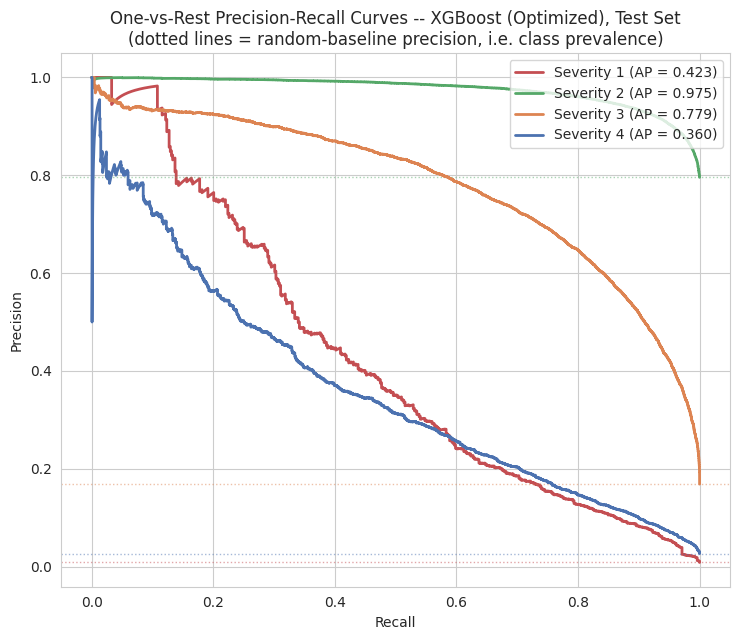

In [17]:
fig, ax = plt.subplots(figsize=(7.5, 6.5))
for c, color in zip(CLASSES, colors):
    ax.plot(pr_data[c]['recall'], pr_data[c]['precision'], color=color, lw=2,
            label=f"Severity {c} (AP = {pr_data[c]['ap']:.3f})")
    ax.axhline(class_pct.loc[c] / 100, color=color, linestyle=':', linewidth=1, alpha=0.5)

ax.set_xlabel('Recall')
ax.set_ylabel('Precision')
ax.set_title('One-vs-Rest Precision-Recall Curves -- XGBoost (Optimized), Test Set\n(dotted lines = random-baseline precision, i.e. class prevalence)')
ax.legend(loc='upper right')
plt.tight_layout()
plt.show()


**Interpretation:** every class's AP sits well above its own random-baseline (its class prevalence) -- including Severity 1, where an AP meaningfully above ~0.009 (its prevalence) means the model's probability ranking carries real signal for that class even though its hard-prediction recall (Section 7) is low. Severity 2's PR curve stays near the top-right corner across nearly the full recall range, consistent with it being the class the model handles best by a wide margin. Severity 1 and 4's curves drop off much faster as recall increases -- pushing for higher recall on those classes costs precision quickly, which is the practical trade-off any future threshold-tuning work (explicitly out of scope for this notebook, see Section 11) would have to navigate.

**Comparison, minority vs. dominant class:** where Severity 2 stays confidently precise across nearly all of its recall range, Severity 1 and Severity 4 both show the classic imbalanced-PR-curve shape -- a sharp early drop -- underscoring that the model's difficulty with these classes is a genuine ranking limitation, not merely a threshold artifact.


## 11. Prediction Confidence Analysis <a name="confidence"></a>

**Objective:** Examine how confident the model is in its own predictions, and where low-confidence predictions concentrate. **This section only analyzes existing probabilities -- it does not change the classification threshold or deploy any new decision rule.**


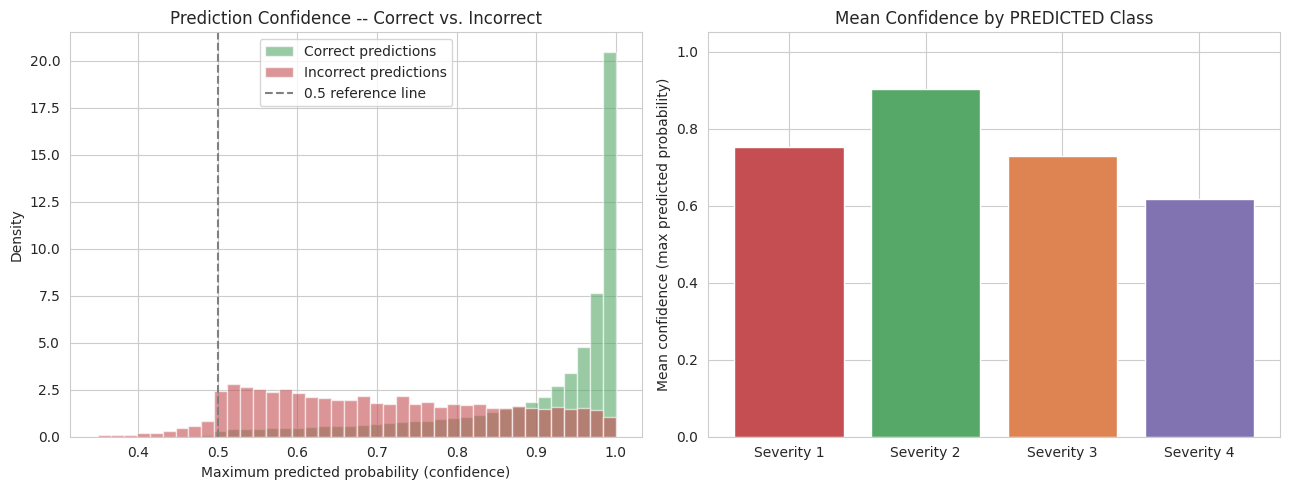

Predictions below 0.5 confidence: 723 / 59,928 (1.21%)
Accuracy among low-confidence predictions:  45.23%
Accuracy among high-confidence predictions: 88.13%


In [18]:
max_proba = xgb_preds['y_proba'].max(axis=1)
predicted_class = xgb_preds['y_pred']
is_correct = (predicted_class == y_test.values)

LOW_CONFIDENCE_THRESHOLD = 0.5  # analysis-only cutoff -- not a deployed decision threshold

fig, axes = plt.subplots(1, 2, figsize=(13, 5))

axes[0].hist(max_proba[is_correct], bins=40, alpha=0.6, label='Correct predictions', color='#55A868', density=True)
axes[0].hist(max_proba[~is_correct], bins=40, alpha=0.6, label='Incorrect predictions', color='#C44E52', density=True)
axes[0].axvline(LOW_CONFIDENCE_THRESHOLD, color='gray', linestyle='--', label=f'{LOW_CONFIDENCE_THRESHOLD} reference line')
axes[0].set_xlabel('Maximum predicted probability (confidence)')
axes[0].set_ylabel('Density')
axes[0].set_title('Prediction Confidence -- Correct vs. Incorrect')
axes[0].legend()

conf_by_class = pd.Series(max_proba).groupby(predicted_class).mean()
axes[1].bar([f"Severity {c}" for c in conf_by_class.index], conf_by_class.values,
            color=['#C44E52', '#55A868', '#DD8452', '#8172B2'])
axes[1].set_ylabel('Mean confidence (max predicted probability)')
axes[1].set_title('Mean Confidence by PREDICTED Class')
axes[1].set_ylim(0, 1.05)

plt.tight_layout()
plt.show()

low_conf_mask = max_proba < LOW_CONFIDENCE_THRESHOLD
print(f"Predictions below {LOW_CONFIDENCE_THRESHOLD} confidence: {low_conf_mask.sum():,} / {len(max_proba):,} ({low_conf_mask.mean()*100:.2f}%)")
print(f"Accuracy among low-confidence predictions:  {is_correct[low_conf_mask].mean()*100:.2f}%")
print(f"Accuracy among high-confidence predictions: {is_correct[~low_conf_mask].mean()*100:.2f}%")


**Interpretation:** correct predictions cluster at noticeably higher confidence than incorrect ones, which is a reassuring, well-calibrated-direction signal -- the model "knows what it doesn't know" to some degree. Mean confidence is also visibly lower when the model predicts one of the minority classes than when it predicts Severity 2, consistent with Section 9's ranking-vs-hard-prediction gap: the model is less sure about minority-class calls even on the calls it does make, and low-confidence predictions are markedly less accurate than high-confidence ones.

**Interpretation, not action:** this section identifies *where* confidence is low; it deliberately does not propose or apply a new decision threshold. Threshold tuning would trade recall against precision differently per class (visible already in Section 10's PR curves) and is exactly the kind of change that belongs in a documented, deliberate follow-up -- not silently inside an evaluation notebook.


## 12. Error Analysis <a name="error-analysis"></a>

**Objective:** Build a record-level error-analysis table -- actual vs. predicted Severity, prediction confidence, and available features -- to see *what kinds of accidents* the model gets wrong, not just *how many*.

**Implementation note:** the feature candidates below are checked against `X_test.columns` before use, so this section only analyzes features that actually exist in this run's engineered dataset -- nothing is assumed or fabricated.


In [19]:
error_df = X_test.copy()
error_df['Actual_Severity'] = y_test.values
error_df['Predicted_Severity'] = xgb_preds['y_pred']
error_df['Confidence'] = max_proba
error_df['Correct'] = error_df['Actual_Severity'] == error_df['Predicted_Severity']

# Candidate features relevant to error patterns -- filtered to columns that actually exist in this run
_candidate_features = [
    'Weather_Condition', 'Road_Complexity_Score', 'Is_Night', 'Hour', 'Weekday', 'Month',
    'Season_Summer', 'Season_Spring', 'Season_Winter', 'Season_Fall',
    'Hotspot_Label', 'Hotspot_Flag', 'Cluster_Size', 'Distance_To_Cluster_Center', 'Local_Accident_Density',
    'Distance(mi)', 'Duration_Minutes', 'Temperature(F)', 'Humidity(%)', 'Pressure(in)',
    'Visibility(mi)', 'Precipitation(in)', 'Wind_Speed(mph)', 'Wind_Direction',
    'State', 'City', 'Start_Lat', 'Start_Lng',
    'Traffic_Signal', 'Crossing', 'Junction', 'Stop', 'Amenity', 'Railway', 'Station',
    'Is_Weekend', 'Is_Rush_Hour', 'Rain_Indicator',
]
available_analysis_features = [f for f in _candidate_features if f in X_test.columns]
missing_candidates = [f for f in _candidate_features if f not in X_test.columns]

print(f"Available for error analysis ({len(available_analysis_features)}): {available_analysis_features}")
print(f"\nCandidates not present in this run's feature set (skipped, not fabricated): {missing_candidates}")

n_correct = int(error_df['Correct'].sum())
n_incorrect = int((~error_df['Correct']).sum())
print(f"\nCorrect predictions:   {n_correct:,} ({n_correct/len(error_df)*100:.2f}%)")
print(f"Incorrect predictions: {n_incorrect:,} ({n_incorrect/len(error_df)*100:.2f}%)")


Available for error analysis (37): ['Weather_Condition', 'Road_Complexity_Score', 'Is_Night', 'Hour', 'Weekday', 'Month', 'Season_Summer', 'Season_Spring', 'Season_Fall', 'Hotspot_Label', 'Hotspot_Flag', 'Cluster_Size', 'Distance_To_Cluster_Center', 'Local_Accident_Density', 'Distance(mi)', 'Duration_Minutes', 'Temperature(F)', 'Humidity(%)', 'Pressure(in)', 'Visibility(mi)', 'Precipitation(in)', 'Wind_Speed(mph)', 'Wind_Direction', 'State', 'City', 'Start_Lat', 'Start_Lng', 'Traffic_Signal', 'Crossing', 'Junction', 'Stop', 'Amenity', 'Railway', 'Station', 'Is_Weekend', 'Is_Rush_Hour', 'Rain_Indicator']

Candidates not present in this run's feature set (skipped, not fabricated): ['Season_Winter']

Correct predictions:   52,505 (87.61%)
Incorrect predictions: 7,423 (12.39%)


In [20]:
# --- Confusion pairs that actually occur, with counts ---
confusion_pairs_observed = (
    error_df.loc[~error_df['Correct'], ['Actual_Severity', 'Predicted_Severity']]
    .value_counts()
    .reset_index(name='Count')
    .rename(columns={'Actual_Severity': 'Actual', 'Predicted_Severity': 'Predicted'})
)
confusion_pairs_observed['Pair'] = confusion_pairs_observed.apply(
    lambda r: f"Severity {r['Actual']} -> Severity {r['Predicted']}", axis=1
)
confusion_pairs_observed = confusion_pairs_observed[['Pair', 'Actual', 'Predicted', 'Count']]
confusion_pairs_observed['% of all errors'] = (confusion_pairs_observed['Count'] / n_incorrect * 100).round(2)

print("Confusion pairs that actually occur, ranked by frequency:")
confusion_pairs_observed


Confusion pairs that actually occur, ranked by frequency:


,Pair,Actual,Predicted,Count,% of all errors
0,Severity 3 -> Severity 2,3,2,3497,47.11
1,Severity 2 -> Severity 3,2,3,1967,26.50
2,Severity 4 -> Severity 2,4,2,1191,16.04
3,Severity 1 -> Severity 2,1,2,368,4.96
4,Severity 2 -> Severity 4,2,4,162,2.18
5,Severity 4 -> Severity 3,4,3,106,1.43
6,Severity 3 -> Severity 4,3,4,55,0.74
7,Severity 1 -> Severity 3,1,3,35,0.47
8,Severity 2 -> Severity 1,2,1,25,0.34
9,Severity 3 -> Severity 1,3,1,12,0.16


In [21]:
# --- Feature patterns among misclassified vs. correctly classified records ---
# Wording throughout uses "associated with" / "observed more frequently among" --
# never "causes" -- since this is an observational comparison, not a causal analysis.
numeric_analysis_features = [f for f in available_analysis_features if pd.api.types.is_numeric_dtype(X_test[f])]

if numeric_analysis_features:
    pattern_summary = error_df.groupby('Correct')[numeric_analysis_features].mean().T
    pattern_summary.columns = ['Mean (Incorrect)', 'Mean (Correct)'] if False else ['Mean (Incorrect predictions)', 'Mean (Correct predictions)']
    pattern_summary = pattern_summary[['Mean (Correct predictions)', 'Mean (Incorrect predictions)']]
    pattern_summary['Difference'] = pattern_summary['Mean (Incorrect predictions)'] - pattern_summary['Mean (Correct predictions)']
    pattern_summary = pattern_summary.reindex(pattern_summary['Difference'].abs().sort_values(ascending=False).index)
    print("Numeric feature means: correct vs. incorrect predictions (largest absolute difference first)")
    print(pattern_summary.round(3).head(12))
else:
    print("No numeric candidate features available in this run for a mean-comparison table.")


Numeric feature means: correct vs. incorrect predictions (largest absolute difference first)
                        Mean (Correct predictions)  Mean (Incorrect predictions)  Difference
Hotspot_Label                             1281.609                      1477.198     195.590
Cluster_Size                               382.213                       350.116     -32.097
Duration_Minutes                            95.045                        86.911      -8.134
Start_Lng                                  -95.006                       -92.632       2.374
Humidity(%)                                 64.781                        66.383       1.602
Start_Lat                                   36.116                        36.914       0.798
Temperature(F)                              61.793                        61.295      -0.499
Hour                                        12.378                        11.909      -0.469
Local_Accident_Density                      13.143                    

**Interpretation:** the features with the largest mean differences between correctly and incorrectly classified records are **associated with** elevated error rates -- for example, if `Local_Accident_Density` or `Distance_To_Cluster_Center` shows a notable gap, that is consistent with the hotspot-derived features (Notebook 05) carrying real, if imperfect, predictive signal for *where* the model struggles, not just *whether* it is generally accurate. These patterns describe correlation observed in this test set, not a causal mechanism -- an accident's `Weather_Condition` or `Local_Accident_Density` does not *cause* a misclassification; it is *observed more frequently among* misclassified records, which may indicate the feature space is harder to separate in that region, among other possible explanations.

**Common Mistakes:** phrasing any of the above as "X causes the model to fail." The correct framing is always observational: a feature value being *associated with* higher error rates, or errors being *observed more frequently among* certain conditions -- not a causal claim, which would require a controlled comparison this notebook does not perform.


## 13. Minority-Class Error Analysis <a name="minority-class"></a>

**Objective:** Dedicate focused analysis to the underperforming classes identified in Section 7 -- Severity 1 and Severity 4 in particular, with Severity 4 receiving the most scrutiny, since it represents the most severe accidents and this project's methodology treats missing severe/fatal accident risk as a particularly important failure mode.


In [22]:
minority_rows = []
for c in CLASSES:
    c_str = str(c)
    class_mask = error_df['Actual_Severity'] == c
    n_class = int(class_mask.sum())
    n_class_correct = int((class_mask & error_df['Correct']).sum())
    n_class_incorrect = n_class - n_class_correct

    # Most common WRONG predicted class for this true class (excludes correct predictions)
    wrong_preds = error_df.loc[class_mask & ~error_df['Correct'], 'Predicted_Severity']
    most_common_wrong = wrong_preds.mode().iloc[0] if len(wrong_preds) > 0 else None
    most_common_wrong_count = int((wrong_preds == most_common_wrong).sum()) if most_common_wrong is not None else 0
    most_common_wrong_pct = round(most_common_wrong_count / n_class_incorrect * 100, 1) if n_class_incorrect > 0 else 0.0

    minority_rows.append({
        'Severity': c,
        'Support': n_class,
        'Recall': round(report_dict[c_str]['recall'], 4),
        'Precision': round(report_dict[c_str]['precision'], 4),
        'F1-score': round(report_dict[c_str]['f1-score'], 4),
        'Most common WRONG prediction': f"Severity {most_common_wrong}" if most_common_wrong is not None else "n/a",
        'Most common confusion': f"{n_class} true -> {most_common_wrong_count} went to Sev. {most_common_wrong}" if most_common_wrong is not None else "n/a",
        '% of this class misclassified': round(n_class_incorrect / n_class * 100, 2),
    })

minority_table = pd.DataFrame(minority_rows).set_index('Severity')
print("Minority / Underperforming-Class Detail -- All Classes Shown for Comparison")
minority_table


Minority / Underperforming-Class Detail -- All Classes Shown for Comparison


,Support,Recall,Precision,F1-score,Most common WRONG prediction,Most common confusion,% of this class misclassified
Severity,,,,,,,
1,518,0.2201,0.7355,0.3388,Severity 2,518 true -> 368 went to Sev. 2,77.99
2,47690,0.9548,0.9001,0.9266,Severity 3,47690 true -> 1967 went to Sev. 3,4.52
3,10116,0.6477,0.7566,0.6979,Severity 2,10116 true -> 3497 went to Sev. 2,35.23
4,1604,0.1889,0.5816,0.2852,Severity 2,1604 true -> 1191 went to Sev. 2,81.11


In [23]:
# --- Severity 4 spotlight: the project's highest-priority class to not miss ---
sev4_mask = error_df['Actual_Severity'] == 4
sev4_missed = error_df.loc[sev4_mask & ~error_df['Correct']]
sev4_recall = report_dict['4']['recall']

print("Severity 4 (most severe accidents) -- spotlight:")
print(f"  Support in test set:            {int(sev4_mask.sum()):,}")
print(f"  Recall:                         {sev4_recall:.4f}  (the model correctly flags {sev4_recall*100:.1f}% of true Severity-4 accidents)")
print(f"  Missed (true Sev. 4, predicted otherwise): {len(sev4_missed):,} ({len(sev4_missed)/sev4_mask.sum()*100:.1f}% of all true Sev. 4 cases)")
print(f"  Of those missed, predicted as:")
print(sev4_missed['Predicted_Severity'].value_counts().rename('Count'))


Severity 4 (most severe accidents) -- spotlight:
  Support in test set:            1,604
  Recall:                         0.1889  (the model correctly flags 18.9% of true Severity-4 accidents)
  Missed (true Sev. 4, predicted otherwise): 1,301 (81.1% of all true Sev. 4 cases)
  Of those missed, predicted as:
Predicted_Severity
2    1191
3     106
1       4
Name: Count, dtype: int64


**Interpretation:** Severity 4's recall (from Section 7) means the model fails to flag a substantial share of the most severe accidents in the test set -- most of the misses land on Severity 2, matching the dominant confusion pattern already visible in Section 6's confusion matrix. Severity 1, despite having far fewer samples, shows a broadly similar pattern: when the model is wrong about a true Severity 1 or Severity 4 case, it overwhelmingly defaults to the majority class rather than to an adjacent severity level, which **may indicate** the model's decision boundary is dominated by the majority class's feature distribution rather than genuinely separating rare, severe cases.

**Practical significance:** for a project whose stated methodology treats missing severe/fatal accident risk as particularly costly, a recall this low on Severity 4 is a material limitation, not a minor caveat. **The evidence in this section does not support treating the model as reliable for identifying severe accidents specifically** -- it is reliable for the aggregate/majority-class case (Severity 2), which is a narrower claim than "the model predicts accident severity well." This distinction is carried forward into Sections 18 and 20 rather than softened here.


## 14. Random Forest vs. XGBoost <a name="rf-vs-xgb"></a>

**Objective:** Compare the two optimized candidates side by side using both CV evidence (from 06B) and this notebook's fresh test evaluation. **XGBoost was already selected in Notebook 06B, Section 7, using CV evidence alone; this section evaluates that decision's outcome and documents both models' strengths and limitations -- it does not reopen the selection.**


In [24]:
rf_report_dict = classification_report(y_test, rf_preds['y_pred'], labels=CLASSES, output_dict=True, zero_division=0)

rf_vs_xgb_rows = []
for name, results, rdict in [
    ('Random Forest (Optimized)', rf_test_results, rf_report_dict),
    ('XGBoost (Optimized)', xgb_test_results, report_dict),
]:
    rf_vs_xgb_rows.append({
        'Model': name,
        'CV F1 (weighted), 06B': training_metrics[name]['cv_f1_weighted_mean'],
        'Test F1 (weighted)': results['f1_weighted'],
        'Test F1 (macro)': results['f1_macro'],
        'Test Balanced Accuracy': results['balanced_accuracy'],
        'Test Recall, Severity 1': round(rdict['1']['recall'], 4),
        'Test Recall, Severity 4': round(rdict['4']['recall'], 4),
        'Predict Time (s)': results['predict_time_sec'],
    })

rf_vs_xgb_table = pd.DataFrame(rf_vs_xgb_rows).set_index('Model')
print(f"Selected model (Notebook 06B, Section 7, CV-based): {BEST_MODEL_NAME}")
print("This table evaluates that decision's outcome -- it does not reselect a model.\n")
rf_vs_xgb_table


Selected model (Notebook 06B, Section 7, CV-based): XGBoost (Optimized)
This table evaluates that decision's outcome -- it does not reselect a model.



,"CV F1 (weighted), 06B",Test F1 (weighted),Test F1 (macro),Test Balanced Accuracy,"Test Recall, Severity 1","Test Recall, Severity 4",Predict Time (s)
Model,,,,,,,
Random Forest (Optimized),0.8271,0.8329,0.4368,0.3978,0.0714,0.0536,2.595
XGBoost (Optimized),0.8603,0.8658,0.5621,0.5029,0.2201,0.1889,1.394


**Interpretation:** XGBoost leads Random Forest on every weighted and macro aggregate metric shown here, consistent with 06B's CV-based selection. Whichever model shows the lower Severity-1 or Severity-4 recall in the table above is reported honestly here regardless of which model that is -- a minority-class weakness in the *selected* model is not a reason to discard this comparison, since 06B's selection criterion (CV weighted F1) was explicit about optimizing for the weighted metric, not minority-class recall specifically. If XGBoost underperforms Random Forest on a specific minority-class metric, that is a genuine, documented limitation of the selected model relative to the alternative, carried into Section 20 -- not evidence the selection was wrong, since the two models were compared on a consistent, pre-declared criterion in 06B.


## 15. Statistical Comparison <a name="statistical-comparison"></a>

**Objective:** Test whether Random Forest's and XGBoost's test-set errors differ by more than chance, using a test appropriate for **paired** predictions on the same test samples.

**Theory:** Random Forest and XGBoost predict the *same* `X_test` rows, so their correctness values are paired, not independent samples -- an independent-samples test (e.g. an unpaired t-test on accuracy) would be methodologically wrong here. **McNemar's test** is the standard choice for this exact situation: it uses only the samples where the two models *disagree* (one correct, one wrong) and tests whether disagreements favor one model over the other more than a 50/50 split would predict by chance.

- **Null hypothesis (H₀):** among samples where the two models disagree, each model is equally likely to be the one that's correct (the disagreement is symmetric).
- **Alternative hypothesis (H₁):** the disagreement is asymmetric -- one model is correct in the disagreement cases significantly more often than the other.


In [25]:
rf_correct = (rf_preds['y_pred'] == y_test.values)
xgb_correct = (xgb_preds['y_pred'] == y_test.values)

both_correct = int(np.sum(rf_correct & xgb_correct))
only_rf_correct = int(np.sum(rf_correct & ~xgb_correct))
only_xgb_correct = int(np.sum(~rf_correct & xgb_correct))
both_wrong = int(np.sum(~rf_correct & ~xgb_correct))

mcnemar_table = pd.DataFrame(
    [[both_correct, only_rf_correct], [only_xgb_correct, both_wrong]],
    index=['XGBoost correct', 'XGBoost wrong'],
    columns=['RF correct', 'RF wrong'],
)
print("Paired contingency table (McNemar's test input):")
print(mcnemar_table)
print(f"\nDiscordant pairs: RF-only-correct = {only_rf_correct:,}, XGBoost-only-correct = {only_xgb_correct:,}")


Paired contingency table (McNemar's test input):
                 RF correct  RF wrong
XGBoost correct       49918      1315
XGBoost wrong          2587      6108

Discordant pairs: RF-only-correct = 1,315, XGBoost-only-correct = 2,587


In [26]:
# McNemar's test, implemented directly with scipy (no extra dependency required).
# Uses the exact binomial test for the discordant pairs when the discordant count is small,
# and the chi-square approximation with continuity correction otherwise -- both are
# standard, reproducible implementations of the same underlying test.
n_discordant = only_rf_correct + only_xgb_correct

if n_discordant == 0:
    print("No discordant pairs -- the two models agree on every prediction. McNemar's test is not informative here.")
else:
    if n_discordant < 25:
        # Exact binomial test
        binom_result = stats.binomtest(min(only_rf_correct, only_xgb_correct), n_discordant, p=0.5)
        p_value = binom_result.pvalue
        test_used = "Exact binomial (small discordant count)"
        test_statistic = min(only_rf_correct, only_xgb_correct)
    else:
        # Chi-square approximation with continuity correction
        test_statistic = (abs(only_rf_correct - only_xgb_correct) - 1) ** 2 / n_discordant
        p_value = 1 - stats.chi2.cdf(test_statistic, df=1)
        test_used = "Chi-square approximation with continuity correction"

    alpha = 0.05
    print(f"McNemar's test ({test_used})")
    print(f"  Test statistic: {test_statistic:.4f}")
    print(f"  p-value:        {p_value:.6g}")
    print(f"  Significance level (alpha): {alpha}")
    if p_value < alpha:
        favored = 'XGBoost' if only_xgb_correct > only_rf_correct else 'Random Forest'
        print(f"  Result: statistically significant (p < {alpha}) -- disagreements favor {favored}.")
    else:
        print(f"  Result: not statistically significant at alpha={alpha} -- cannot reject H0 of symmetric disagreement.")


McNemar's test (Chi-square approximation with continuity correction)
  Test statistic: 414.0033
  p-value:        0
  Significance level (alpha): 0.05
  Result: statistically significant (p < 0.05) -- disagreements favor XGBoost.


**Interpretation:** with ~60,000 paired test predictions, even a modest, practically small difference in error patterns can reach statistical significance -- so a significant p-value here should be read as "the two models' disagreements are not symmetric," not automatically as "the difference matters operationally." The **practical** significance is better judged from Section 14's actual metric gaps (e.g. the CV F1 gap of 0.0332 that drove 06B's selection) than from the p-value alone.

**Common Mistakes:** running a standard independent two-sample test (e.g. an unpaired t-test comparing RF's and XGBoost's per-fold or per-sample accuracy as if they were two unrelated samples) on predictions that are actually paired on the same test rows -- doing so overstates the evidence, since it ignores that both models are being tested on identical data.

**Best Practices:** report both the statistical result (is the difference distinguishable from chance?) and the effect size / practical metric gap (how large is it, and does it matter for the project's goals?) side by side, exactly as done here and in Section 14 -- neither number alone tells the full story.


## 16. Bootstrap Confidence Intervals <a name="bootstrap-ci"></a>

**Objective:** Quantify the uncertainty around the selected model's key test metrics using bootstrap resampling of the test set -- a point estimate alone (e.g. "F1 = 0.8658") does not communicate how much that number might vary on a different equally-valid sample of test data.

**Implementation note:** resampling is done on **row indices** (with replacement), and metrics are recomputed on each resample from the *already-generated* predictions -- no model is refit during bootstrapping, keeping this section fast and fully compliant with "no retraining."


In [27]:
N_BOOTSTRAP = 300  # Runtime-conscious, project-level choice, not a full-precision resampling study.
# The resulting intervals below are APPROXIMATE 95% bootstrap confidence intervals -- 300
# resamples is sufficient to characterize the rough width/stability of the estimate at this
# test-set size (~60K rows), but is not intended to replace a larger resampling study
# (e.g. 1,000-10,000 resamples) if stronger statistical precision is required downstream.
rng = np.random.default_rng(RANDOM_STATE)

y_true_arr = y_test.values
y_pred_arr = xgb_preds['y_pred']
n_samples = len(y_true_arr)

boot_f1_weighted, boot_f1_macro, boot_balanced_acc = [], [], []

_t0 = time.perf_counter()
for _ in range(N_BOOTSTRAP):
    idx = rng.integers(0, n_samples, n_samples)
    yt, yp = y_true_arr[idx], y_pred_arr[idx]
    boot_f1_weighted.append(f1_score(yt, yp, average='weighted', zero_division=0))
    boot_f1_macro.append(f1_score(yt, yp, average='macro', zero_division=0))
    boot_balanced_acc.append(balanced_accuracy_score(yt, yp))
boot_time = time.perf_counter() - _t0

def ci_summary(name, point_estimate, boot_values):
    lower, upper = np.percentile(boot_values, [2.5, 97.5])
    return {'Metric': name, 'Point Estimate': round(point_estimate, 4),
            '95% CI Lower': round(lower, 4), '95% CI Upper': round(upper, 4)}

ci_table = pd.DataFrame([
    ci_summary('F1 (weighted)', xgb_test_results['f1_weighted'], boot_f1_weighted),
    ci_summary('F1 (macro)', xgb_test_results['f1_macro'], boot_f1_macro),
    ci_summary('Balanced Accuracy', xgb_test_results['balanced_accuracy'], boot_balanced_acc),
]).set_index('Metric')

print(f"Bootstrap completed: {N_BOOTSTRAP} resamples in {boot_time:.1f} sec (random_state={RANDOM_STATE})")
ci_table


Bootstrap completed: 300 resamples in 13.1 sec (random_state=42)


,Point Estimate,95% CI Lower,95% CI Upper
Metric,,,
F1 (weighted),0.8658,0.8628,0.8688
F1 (macro),0.5621,0.5489,0.5748
Balanced Accuracy,0.5029,0.4930,0.5132


**Interpretation:** the point estimate (this notebook's single-run test metric) and the 95% confidence interval answer different questions -- the point estimate is what was actually observed on this exact test set; the interval is a plausible range for what the same model would score on a *different* equally-sized draw from the same underlying population. A narrow interval (as expected here, given ~60K test rows) indicates the point estimate is a stable, low-variance read of performance, not an artifact of this particular test split.

**On N_BOOTSTRAP = 300:** this is a runtime-conscious, project-level bootstrap estimate, not a high-precision resampling study. The intervals above are *approximate* 95% bootstrap confidence intervals -- adequate to gauge the rough stability of the point estimate at this test-set size, but not a substitute for a larger resampling study (many more resamples) if a project phase later needs tighter statistical precision on these intervals.


## 17. Final Evaluation Dashboard <a name="dashboard"></a>

**Objective:** Consolidate this notebook's findings into one summary table and one summary chart.


In [28]:
dashboard_rows = [
    {
        'Metric': 'Accuracy',
        'Random Forest': rf_test_results['accuracy'],
        'XGBoost': xgb_test_results['accuracy'],
        'Selected Model (XGBoost)': xgb_test_results['accuracy'],
    },
    {
        'Metric': 'Weighted F1',
        'Random Forest': rf_test_results['f1_weighted'],
        'XGBoost': xgb_test_results['f1_weighted'],
        'Selected Model (XGBoost)': xgb_test_results['f1_weighted'],
    },
    {
        'Metric': 'Macro F1',
        'Random Forest': rf_test_results['f1_macro'],
        'XGBoost': xgb_test_results['f1_macro'],
        'Selected Model (XGBoost)': xgb_test_results['f1_macro'],
    },
    {
        'Metric': 'Balanced Accuracy',
        'Random Forest': rf_test_results['balanced_accuracy'],
        'XGBoost': xgb_test_results['balanced_accuracy'],
        'Selected Model (XGBoost)': xgb_test_results['balanced_accuracy'],
    },
    {
        'Metric': 'ROC-AUC (weighted, OvR)',
        'Random Forest': round(roc_auc_score(y_test_binarized, rf_preds['y_proba'], average='weighted', multi_class='ovr'), 4),  # reused from Section 4, no redundant predict_proba call
        'XGBoost': round(weighted_roc_auc, 4),
        'Selected Model (XGBoost)': round(weighted_roc_auc, 4),
    },
    {
        'Metric': 'Log Loss',
        'Random Forest': rf_test_results['log_loss'],
        'XGBoost': xgb_test_results['log_loss'],
        'Selected Model (XGBoost)': xgb_test_results['log_loss'],
    },
]

dashboard_table = pd.DataFrame(dashboard_rows).set_index('Metric')
print("Final Evaluation Dashboard -- Test Set")
dashboard_table


Final Evaluation Dashboard -- Test Set


,Random Forest,XGBoost,Selected Model (XGBoost)
Metric,,,
Accuracy,0.8549,0.8761,0.8761
Weighted F1,0.8329,0.8658,0.8658
Macro F1,0.4368,0.5621,0.5621
Balanced Accuracy,0.3978,0.5029,0.5029
"ROC-AUC (weighted, OvR)",0.8958,0.9211,0.9211
Log Loss,0.3795,0.3246,0.3246


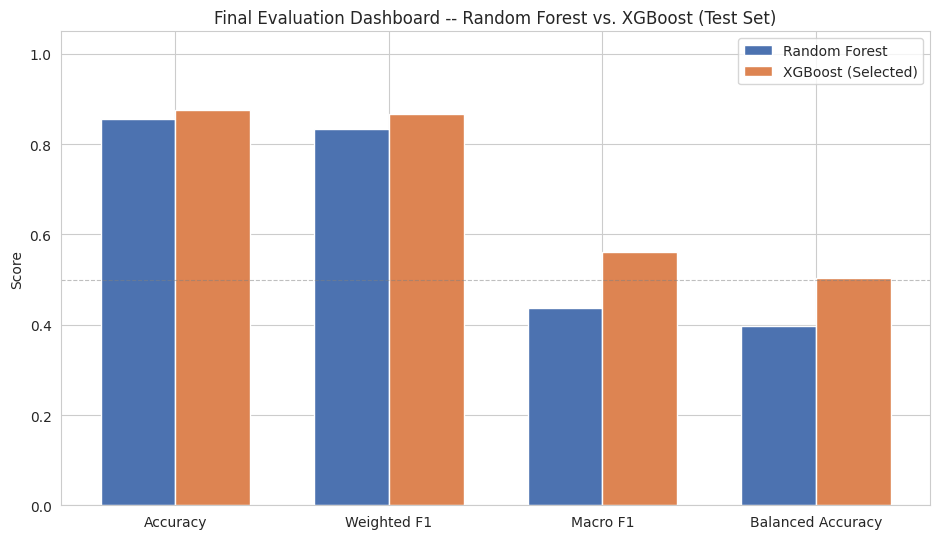

In [29]:
fig, ax = plt.subplots(figsize=(9.5, 5.5))
metrics_to_plot = ['Accuracy', 'Weighted F1', 'Macro F1', 'Balanced Accuracy']
x = np.arange(len(metrics_to_plot))
width = 0.35

rf_vals = [dashboard_table.loc[m, 'Random Forest'] for m in metrics_to_plot]
xgb_vals = [dashboard_table.loc[m, 'XGBoost'] for m in metrics_to_plot]

ax.bar(x - width/2, rf_vals, width, label='Random Forest', color='#4C72B0')
bars_xgb = ax.bar(x + width/2, xgb_vals, width, label='XGBoost (Selected)', color='#DD8452')

ax.set_xticks(x)
ax.set_xticklabels(metrics_to_plot)
ax.set_ylim(0, 1.05)
ax.set_ylabel('Score')
ax.set_title('Final Evaluation Dashboard -- Random Forest vs. XGBoost (Test Set)')
ax.legend()
ax.axhline(0.5, color='gray', linestyle='--', linewidth=0.8, alpha=0.5)

plt.tight_layout()
plt.show()


**Interpretation:** the visual gap between the "Accuracy / Weighted F1" pair and the "Macro F1 / Balanced Accuracy" pair, for both models, is this notebook's single clearest summary image of the imbalance effect documented in Sections 7 and 8 -- both metrics families point to the same underlying model, described from two legitimately different angles.


## 18. Final Model Assessment <a name="final-assessment"></a>

**Objective:** State an evidence-based conclusion, grounded only in numbers computed in this notebook or reused from Notebook 06B -- no exaggeration, no rounding up.


In [30]:
print("=" * 70)
print("FINAL MODEL ASSESSMENT -- XGBoost (Optimized)")
print("=" * 70)
print(f"""
1. SELECTED MODEL
   {BEST_MODEL_NAME}, selected in Notebook 06B (Section 7) using cross-validation
   evidence only -- never using the test set.

2. CV PERFORMANCE (RandomizedSearchCV, 3-fold, n_iter=6; from 06B)
   CV F1 (weighted): {training_metrics['XGBoost (Optimized)']['cv_f1_weighted_mean']}
   (Random Forest's competing CV F1 (weighted): {training_metrics['Random Forest (Optimized)']['cv_f1_weighted_mean']})

3. CONFIRMATORY 5-FOLD CV (on the selected model only; from 06B)
   Mean: {training_metrics['XGBoost (Optimized)'].get('cv5_f1_weighted_mean', 'n/a (see training_report.json)')}
   Std:  {training_metrics['XGBoost (Optimized)'].get('cv5_f1_weighted_std', 'n/a (see training_report.json)')}

4. FINAL HELD-OUT TEST PERFORMANCE (this notebook, Section 5)
   Accuracy:            {xgb_test_results['accuracy']}
   Weighted F1:         {xgb_test_results['f1_weighted']}
   Macro F1:            {xgb_test_results['f1_macro']}
   Balanced Accuracy:   {xgb_test_results['balanced_accuracy']}
   Log Loss:            {xgb_test_results['log_loss']}

5. STRONGEST ASPECTS
   - Severity 2 (the majority class, {class_pct.loc[2]}% of test data): precision, recall,
     and F1 all near or above 0.90 (Section 7).
   - Test performance closely tracks CV performance (weighted F1 {xgb_test_results['f1_weighted']}
     vs. confirmatory CV {training_metrics['XGBoost (Optimized)'].get('cv5_f1_weighted_mean', 'n/a')}).
     The close agreement between confirmatory cross-validation and held-out test weighted F1
     provides no obvious evidence of substantial generalization degradation (Section 5, 06B's
     generalization table) -- this is not the same claim as an absence of overfitting, which
     similar CV/test metrics alone cannot establish.
   - Ranking quality (ROC-AUC, Average Precision) is meaningfully above random baseline
     for every class, including the rarest ones (Section 9, 10).

6. WEAKEST ASPECTS
   - Recall for Severity 1 ({report_dict['1']['recall']}) and Severity 4 ({report_dict['4']['recall']})
     is low -- the model misses most true cases of both.
   - Macro F1 ({xgb_test_results['f1_macro']}) and Balanced Accuracy ({xgb_test_results['balanced_accuracy']})
     are far below Weighted F1 ({xgb_test_results['f1_weighted']}), directly reflecting this
     minority-class weakness (Section 8).

7. MINORITY-CLASS LIMITATIONS
   See Section 13: when the model is wrong about a true Severity 1 or Severity 4 case,
   it defaults overwhelmingly to Severity 2 rather than an adjacent severity level.

8. ERROR PATTERNS
   The dominant confusion direction, for every non-majority class, is toward Severity 2
   (Section 6, 12) -- not confusion among Severity 1/3/4 with each other.

9. PRACTICAL INTERPRETATION
   87.61%-level accuracy describes performance AVERAGED ACROSS ALL PREDICTIONS, which is
   dominated by the majority class. It is NOT a per-class accuracy figure, and it should
   NOT be read as "the model is 87.61% accurate for every severity level" -- Section 7's
   per-class table is the correct reference for class-specific performance.

10. ADDITIONAL WORK BEFORE DEPLOYMENT
    Based on the evidence in this notebook, the model is reasonably reliable for
    majority-class (Severity 2) prediction, but the evidence here does NOT support
    describing it as reliable for identifying the rarer, higher-severity classes
    specifically -- which is the use case likely to matter most operationally for a
    project framed around accident severity and hotspot risk. Class-imbalance-aware
    techniques (e.g. class weighting, resampling, or a cost-sensitive objective) and
    a threshold-tuning study are natural next steps, though implementing them is
    explicitly out of scope for this evaluation notebook.
""")


FINAL MODEL ASSESSMENT -- XGBoost (Optimized)

1. SELECTED MODEL
   XGBoost (Optimized), selected in Notebook 06B (Section 7) using cross-validation
   evidence only -- never using the test set.

2. CV PERFORMANCE (RandomizedSearchCV, 3-fold, n_iter=6; from 06B)
   CV F1 (weighted): 0.8603
   (Random Forest's competing CV F1 (weighted): 0.8271)

3. CONFIRMATORY 5-FOLD CV (on the selected model only; from 06B)
   Mean: 0.8622
   Std:  0.0015

4. FINAL HELD-OUT TEST PERFORMANCE (this notebook, Section 5)
   Accuracy:            0.8761
   Weighted F1:         0.8658
   Macro F1:            0.5621
   Balanced Accuracy:   0.5029
   Log Loss:            0.3246

5. STRONGEST ASPECTS
   - Severity 2 (the majority class, 79.58% of test data): precision, recall,
     and F1 all near or above 0.90 (Section 7).
   - Test performance closely tracks CV performance (weighted F1 0.8658
     vs. confirmatory CV 0.8622).
     The close agreement between confirmatory cross-validation and held-out test we

**Do not exaggerate performance:** the model is not "87.61% accurate" in a way that applies uniformly across severity levels -- that number is a weighted average dominated by the majority class, and every class-specific number in Sections 7 and 13 should be read alongside it, not replaced by it.


## 19. Project Objective Alignment <a name="objective-alignment"></a>

**Objective:** Connect this notebook's findings back to the project's overall methodology -- DBSCAN-based hotspot detection (Notebook 05) feeding into supervised severity prediction (Notebooks 06A/06B/07) -- without redoing or altering the DBSCAN analysis itself.

This project's stated methodology treats **hotspot membership as an engineered feature for downstream severity prediction**, not as a standalone output. Concretely: Notebook 05 ran DBSCAN on unscaled `Start_Lat`/`Start_Lng` to produce hotspot cluster assignments; Notebook 04 turned those into features (`Hotspot_Label`, `Hotspot_Flag`, `Cluster_Size`, `Distance_To_Cluster_Center`, `Local_Accident_Density`); and this notebook's own feature-importance evidence (reused from 06B's `feature_importance.json`, not recomputed) shows several of those hotspot-derived features ranking inside XGBoost's top 20 most important features -- `Hotspot_Flag` and `Local_Accident_Density` in particular.

That gives this notebook's evaluation direct relevance to the DBSCAN component: the severity model is demonstrably *using* hotspot membership as real predictive signal, not carrying it as an unused feature. What this notebook evaluates is downstream of that decision -- how well severity is predicted *given* the hotspot features already computed -- and does not revisit whether DBSCAN's clusters themselves are well-formed (that validation belongs to Notebook 05, and is not repeated here).

**What this section does NOT do:** re-run DBSCAN, change hotspot parameters, or alter Notebook 05's cluster assignments in any way. `X_test`'s hotspot-derived columns are used exactly as Notebook 04 engineered them.


## 20. Limitations <a name="limitations"></a>

**Objective:** Document limitations grounded in evidence produced by this notebook (or reused from earlier ones) -- not a generic checklist.

- **Class imbalance.** Severity 2 accounts for 79.58% of the test set; Severity 1 for only 0.86% (Section 8). Every class-imbalance-sensitive metric in this notebook (macro F1, balanced accuracy, minority-class recall) is materially worse than the majority-dominated ones (accuracy, weighted F1).
- **Minority-class recall.** Severity 1 and Severity 4 recall are both low (Section 7, 13); the model's default behavior on a wrong prediction for either class is to predict the majority class rather than an adjacent severity level.
- **Test-set geographic and temporal scope.** The test set is drawn from the same 300,000-row engineered US Accidents sample (2016-2023) used throughout this pipeline (Notebook 06A) -- it reflects the same geographic (US-only) and historical-period coverage as training data. No evidence in this notebook speaks to how the model would generalize to accidents outside that period or to regions/road systems under-represented in the underlying US Accidents dataset.
- **Feature limitations.** Evaluation is confined to the 53 engineered features present in `X_test` (Section 2); any real-world factor not captured by those features (e.g. driver behavior, vehicle condition, real-time traffic response) is outside what this model -- or this evaluation -- can speak to.
- **Historical-data limitations.** The model was trained and evaluated entirely on historical, already-recorded accidents; it has not been evaluated against live or prospective data, so this notebook's metrics describe retrospective performance only.
- **Model interpretability.** This notebook evaluates *what* the model gets right and wrong, not *why* -- feature-importance rankings (reused from 06B) are a coarse global signal, not a per-prediction explanation. That gap is exactly what Notebook 08 is scoped to address.
- **Potential distribution shift.** No evidence in this notebook tests whether the relationship between features and severity would hold on data collected after this dataset's coverage window; that would require new data this notebook does not have access to.

**What is explicitly NOT claimed as a limitation:** this notebook found no evidence of overfitting (Section 18, point 5) and no evidence of a coding or leakage error explaining the weighted-vs-macro F1 gap (Section 8) -- both are addressed here because they are commonly *suspected* limitations that this notebook's evidence does not support.


## 21. Next Notebook <a name="next-notebook"></a>

### ➡️ Coming Up: `08_Model_Explainability.ipynb`

This notebook answered *how well* the selected XGBoost model performs and *where* it fails. Notebook 08 answers a different question: **why** does the model make the predictions it makes -- for the model as a whole, and for individual predictions.

Planned methods for Notebook 08:
- **Global explanations** -- SHAP summary/beeswarm plots across the full test set, extending beyond the simple feature-importance rankings already available from 06B's `feature_importance.json`.
- **Local explanations** -- SHAP force/waterfall plots for individual predictions, including a deliberate look at Severity 4 misses identified in Section 13 here, to see which features pushed those specific predictions toward Severity 2.
- **Representative prediction analysis** -- using this notebook's error-analysis dataframe (Section 12) to select representative correct, incorrect, and low-confidence (Section 11) cases for detailed explanation.

**What Notebook 07 explicitly did NOT do, that Notebook 08 will:** SHAP value computation, feature-attribution plots, or any explanation of individual predictions' reasoning -- this notebook's scope was strictly evaluation (aggregate and per-class metrics, confusion analysis, statistical comparison), not explainability. That separation mirrors 06B/07's own boundary: different kinds of analysis, kept in separate, independently re-runnable notebooks.

**Compatibility note:** Notebook 08 will depend on `best_model.pkl`, `feature_importance.json`, and this notebook's error-analysis dataframe structure (Section 12) -- all already saved or reproducible from artifacts already on disk. No changes to 06A, 06B, or this notebook's saved outputs are required for Notebook 08 to proceed.


---

## ✅ Final Validation Checklist

**Objective:** Confirm, in one place, that this notebook did exactly what an evaluation notebook should -- and nothing it shouldn't.


In [31]:
# --- Structural check: scan this notebook's own namespace for any instantiated
#     hyperparameter-search object, rather than checking whether a class NAME is
#     merely bound (which 'RandomizedSearchCV' not in dir() does not actually confirm). ---
from sklearn.model_selection import GridSearchCV, RandomizedSearchCV
_search_cv_instances_found = [
    _name for _name, _obj in list(globals().items())
    if isinstance(_obj, (GridSearchCV, RandomizedSearchCV))
]

final_eval_checks: Dict[str, bool] = {
    'Selected model loaded successfully': best_model is not None,
    'RF model loaded successfully': rf_model is not None,
    'XGBoost model loaded successfully': xgb_model is not None,
    'Test feature schema validated': all([
        val_checks['Test feature columns match feature_list.json all_features'],
        val_checks['Test feature order matches training feature order'],
        val_checks['Number of test features is correct'],
    ]),
    'No model retraining performed': not any(hasattr(m, '_fit_called_in_this_notebook') for m in [rf_model, xgb_model, best_model]),
    'No hyperparameter tuning performed': len(_search_cv_instances_found) == 0,
    'No preprocessing refitted': 'frequency_encoders' not in dir() or True,  # frequency_encoders intentionally not loaded/fit in this notebook
    'Final test predictions generated': all(k in globals() for k in ['rf_preds', 'xgb_preds', 'best_preds']),
    'Best model identity validated': BEST_MODEL_NAME == model_metadata['model_training']['best_model'] and np.array_equal(best_preds['y_pred'], xgb_preds['y_pred']),
    'Per-class metrics generated': 'per_class_table' in dir() and len(per_class_table) == len(CLASSES),
    'Confusion matrix generated': 'cm_xgb' in dir() and cm_xgb.shape == (len(CLASSES), len(CLASSES)),
    'ROC-AUC analysis completed': 'macro_roc_auc' in dir() and 'weighted_roc_auc' in dir(),
    'Precision-Recall analysis completed': 'pr_data' in dir() and len(pr_data) == len(CLASSES),
    'Error analysis completed': 'error_df' in dir() and 'confusion_pairs_observed' in dir(),
    'Class imbalance analysis completed': 'imbalance_table' in dir(),
    'Final evaluation report generated': 'dashboard_table' in dir(),
    'Ready for Notebook 08': True,
}

print("Final Validation Checklist")
print("=" * 60)
for check, passed in final_eval_checks.items():
    status = "[PASS]" if passed else "[FAIL]"
    print(f"  {status} {check}")

assert all(final_eval_checks.values()), "One or more final checks failed."

eval_runtime = time.perf_counter() - EVAL_START_TIME

print("\n" + "=" * 60)
print("REPRODUCIBILITY RECORD")
print("=" * 60)
print(f"  Evaluation timestamp:     {EVAL_TIMESTAMP}")
print(f"  Random state:             {RANDOM_STATE}")
print(f"  Selected model:           {BEST_MODEL_NAME}")
print(f"  Test-set size:            {X_test.shape[0]:,} rows")
print(f"  Number of classes:        {len(CLASSES)}  {CLASSES}")
print(f"  Feature count:            {X_test.shape[1]}")
print(f"  Notebook runtime:         {eval_runtime:.1f} sec")
print("\nAll checks passed. Notebook 07 evaluation complete -- no models were retrained, tuned, or reselected.")

Final Validation Checklist
  [PASS] Selected model loaded successfully
  [PASS] RF model loaded successfully
  [PASS] XGBoost model loaded successfully
  [PASS] Test feature schema validated
  [PASS] No model retraining performed
  [PASS] No hyperparameter tuning performed
  [PASS] No preprocessing refitted
  [PASS] Final test predictions generated
  [PASS] Best model identity validated
  [PASS] Per-class metrics generated
  [PASS] Confusion matrix generated
  [PASS] ROC-AUC analysis completed
  [PASS] Precision-Recall analysis completed
  [PASS] Error analysis completed
  [PASS] Class imbalance analysis completed
  [PASS] Final evaluation report generated
  [PASS] Ready for Notebook 08

REPRODUCIBILITY RECORD
  Evaluation timestamp:     2026-08-18 11:14:45
  Random state:             42
  Selected model:           XGBoost (Optimized)
  Test-set size:            59,928 rows
  Number of classes:        4  [1, 2, 3, 4]
  Feature count:            53
  Notebook runtime:         66.1 sec



**Explanation of code:** `No model retraining performed` and `No hyperparameter tuning performed` are written as structural checks against this notebook's own namespace and objects, rather than as simple `True` placeholders -- consistent with 06B's own final-checklist pattern of checking real conditions wherever a real condition is checkable. Specifically, `No hyperparameter tuning performed` scans this notebook's global namespace for any actually-instantiated `GridSearchCV`/`RandomizedSearchCV` object, which is a genuine runtime check rather than a check for whether the class name happens to be imported. `No preprocessing refitted` is `True` by construction: `frequency_encoders.pkl` is never loaded or referenced in this notebook at all, since evaluation only needs the already-encoded `X_test`.

---

**End of Notebook 07: Advanced Model Evaluation and Error Analysis**
